In [1]:
# Plotting global ozone timeseries for two ensemble members

In [3]:
import os
import xarray as xr
import matplotlib.pyplot as plt
from utils.utils import autosize_figure, get_scenario_config

In [4]:
# === Path Config ===
SAVE_DIR = "/glade/u/home/awells/air_quality_project/plotting/example_workflow/"
model = "CESM2"
scenario = "SSP245_G6"
config = get_scenario_config(model, scenario)
years = config["years"]
dates = f"{years.start}-{years.stop - 1}"

n_samples = 300

# Load data
DIR = f"/glade/work/awells/air_quality/{model}/mortality/ozone/"
ens1_file = f"Global_mortality_{n_samples}samples_{model}_{scenario}_01_{dates}.nc"
ens1_path = os.path.join(DIR, ens1_file)
ens1 = xr.open_dataarray(ens1_path)

ens2_file = f"Global_mortality_{n_samples}samples_{model}_{scenario}_02_{dates}.nc"
ens2_path = os.path.join(DIR, ens2_file)
ens2 = xr.open_dataarray(ens2_path)

ens3_file = f"Global_mortality_{n_samples}samples_{model}_{scenario}_03_{dates}.nc"
ens3_path = os.path.join(DIR, ens3_file)
ens3 = xr.open_dataarray(ens3_path)

In [5]:
def plotting_data(da, q1, q2):
    mean = da.mean("samples")
    p1 = da.quantile(q1, "samples")
    p2 = da.quantile(q2, "samples")
    return mean, p1, p2

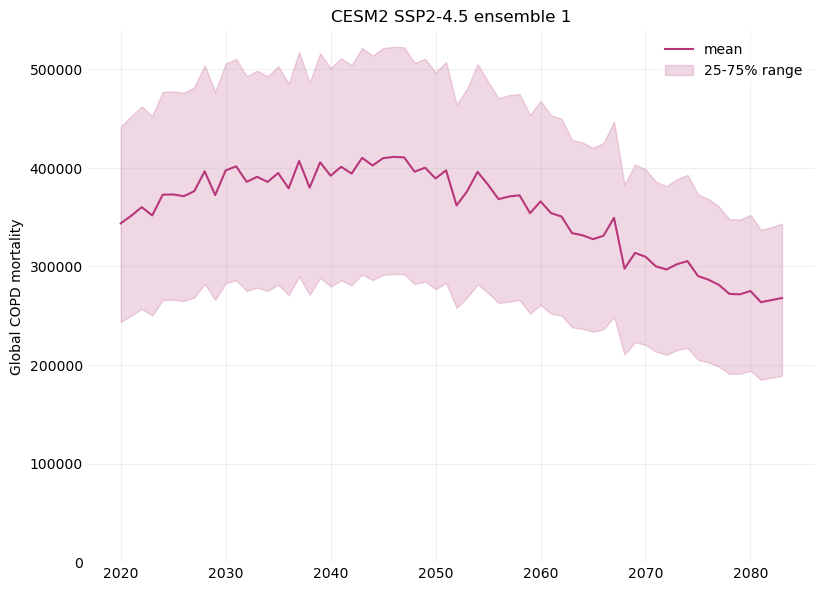

In [39]:
# Quantiles for plotting uncertainty
q1 = 0.25
q2 = 0.75
label = "25-75% range"

da1_mean, da1_p1, da1_p2 = plotting_data(ens1, q1, q2)
da2_mean, da2_p1, da2_p2 = plotting_data(ens2, q1, q2)
da3_mean, da3_p1, da3_p2 = plotting_data(ens3, q1, q2)

plt.figure(figsize=autosize_figure(1, 1))
plt.plot(ens1["year"], da1_mean, color="#B73779", label="mean")
plt.fill_between(ens1["year"], da1_p1, da1_p2, color="#B73779", alpha=0.2, label=label)


plt.ylim(bottom=0)
plt.grid(True, alpha=0.2)
plt.ylabel("Global COPD mortality")
plt.legend(
    frameon=True,
    facecolor="white",
    edgecolor="none",
    framealpha=0.8,
    fontsize=10,
)

plt.title(f"{model} SSP2-4.5 ensemble 1", fontsize=12)

out_file = f"Global_ozone_mortality_{model}_{scenario}_{dates}.png"
out_path = os.path.join(SAVE_DIR, out_file)

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(axis="x", length=0)
ax.tick_params(axis="y", length=0)

plt.tight_layout()
plt.savefig(out_path)
plt.show()